## 데이터 전처리
- 데이터를 분석하기 좋은 형태로 가공하는 과정이다.
- 원본 데이터를 그대로 사용하는 것이 아니라  
  이상치, 중복데이터, 결측치 등을 처리해서 신뢰할 수 있는 데이터로 만드는 과정을 의미한다.

## 이상치(outlier)
- 관측하거나 수집한 데이터의 범위(군집)에서 많이 벗어나있는 아주 작은 값 또는 큰 값을 의미한다.
- 이상치는 제거하거나 대체하거나 또는 가만히 놔둬도 상관없는 지를 판단하여 전처리를 진행해야한다.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRuY-LwTufVlKJ-r54472gZtIxK7CuP0Ei6gVwSRUy8zWdl1koZIG6VzpR6&s=10" />

## 예측
- 숫자로 알기 힘든 값들을 표현하기 위해 기술통계량을 확인하는 것을 의미한다.
- min(최소), max(최대), median(최빈), mean(평균)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [3]:
height_list = [181,280,158,110,170,160,155,145]
avg_height = sum(height_list) / len(height_list)

print(avg_height)
print(min(height_list))
print(max(height_list))

169.875
110
280


## 박스 플롯
- 이상치 탐색을 위해 사용되는 시각화 차트이다.
- 분위수를 기준으로 그려지고, 상자 안에 그려져 있는 직선이 중위수(Median)을 나타낸다. Median값의 위치에 따라 값들의 분포를 확인할 수 있다.
- 상자의 밑변은 1분위수이고, 윗 변은 3분위수를 의미한다.
- 상자의 중심으로 위 아래에 직선이 있는 것을 볼 수 있는데 이 것을 울타리라고 부른다.

### 이상치 계산 공식
- 아래 이상치 공식: 데이터 < Q1 - (1.5 * IQR)
- 위 이상치 공식: 데이터 > Q3 + (1.5 * IQR)
- Q는 분위수를 의미

<img style="width:500px;" src="https://blog.kakaocdn.net/dna/dLPevN/btq1caAZMWD/AAAAAAAAAAAAAAAAAAAAACdUyXIwIBA0UI-lNOxgEND-ivrCO7oAkDQNWYlbYDTf/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=o4DIu2hQNUV89WOVQAkr5VNdrvg%3D" />

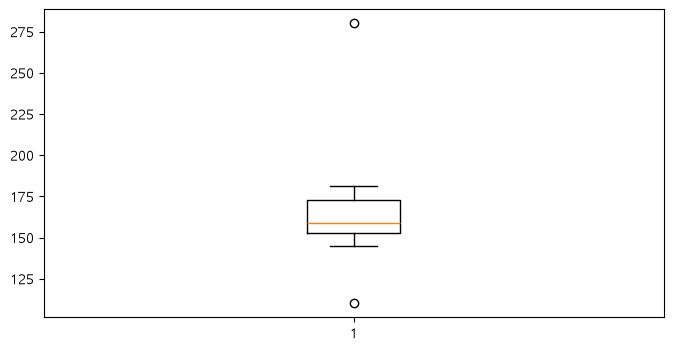

In [4]:
plt.figure(figsize=(8,4))
# 박스플롯: 이상치 탐지할 때 좋음
plt.boxplot(height_list)
plt.show()

In [8]:
height_list = [181,158,170,160,155,145]
avg_height = sum(height_list) / len(height_list)

print(avg_height)
print(min(height_list))
print(max(height_list))

161.5
145
181


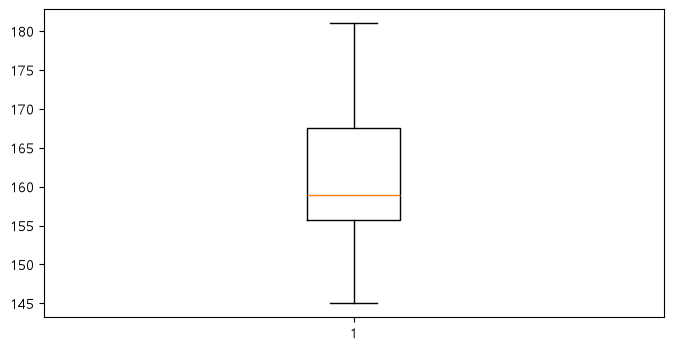

In [9]:
plt.figure(figsize=(8,4))
plt.boxplot(height_list)
plt.show()

## 이상치(Outlier) 처리 방법
1. 값을 그대로 냅둔다.
2. 값을 제거한다(신뢰도 저하, 데이터 버려짐 등의 단점 존재).

## 결측치(Outlier) 처리 방법
- 데이터 수집 또는 데이터셋에서 NULL,NaN 값이 들어가 비어있는 상태를 의미한다.
- 데이터를 수집하는 과정에서 오류, 누락, 값을 저장하는 과정에서 소실한 것을 의미하며 분석 전에 반드시 처리해야 한다.
- 대체한다면 평균값, 최빈값, 중앙값 같은 통계 수치나 머신 러닝의 예측 값 중 적절한 데이터의 특성을 고려하여 대체해야 한다.

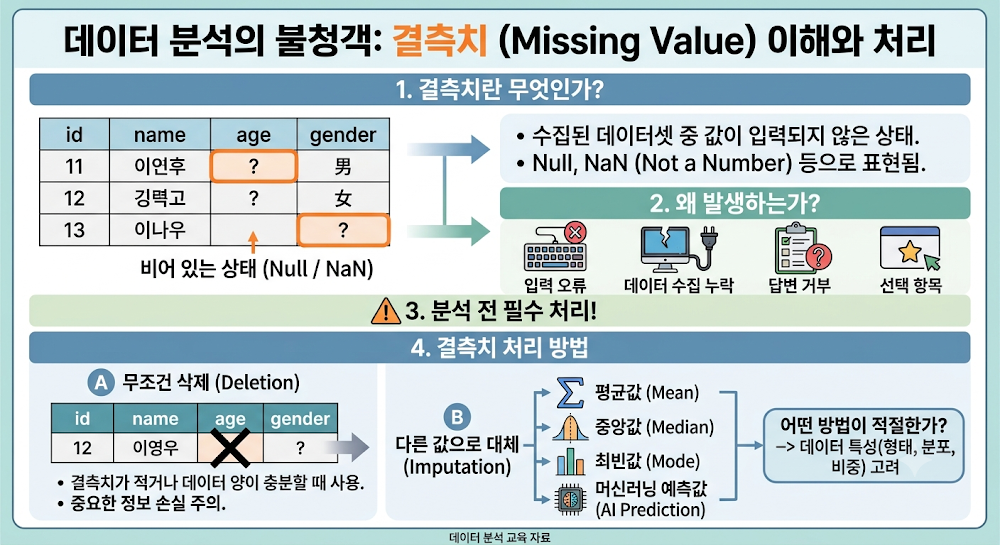

In [59]:
df = pd.DataFrame({
    "이름":["시츄","하아","승연","지성","혜지","승기","우연","소민"],
    "소득":[400000,32323,40320,None,20000,30000,23000,None]
})

df

,이름,소득
0,시츄,400000.0
1,하아,32323.0
2,승연,40320.0
3,지성,NaN
4,혜지,20000.0
5,승기,30000.0
6,우연,23000.0
7,소민,NaN


In [60]:
df.isna().sum()

이름    0
소득    2
dtype: int64

In [61]:
# 결측치를 삭제
df2 = df.dropna()
df2

,이름,소득
0,시츄,400000.0
1,하아,32323.0
2,승연,40320.0
4,혜지,20000.0
5,승기,30000.0
6,우연,23000.0


In [62]:
df["소득"].mean()

np.float64(90940.5)

In [63]:
df

,이름,소득
0,시츄,400000.0
1,하아,32323.0
2,승연,40320.0
3,지성,NaN
4,혜지,20000.0
5,승기,30000.0
6,우연,23000.0
7,소민,NaN


In [64]:
# .fillna() : NaN인 데이터를 채움
df.fillna(df["소득"].mean())

,이름,소득
0,시츄,400000.0
1,하아,32323.0
2,승연,40320.0
3,지성,90940.5
4,혜지,20000.0
5,승기,30000.0
6,우연,23000.0
7,소민,90940.5


## 최빈값: .mode()

In [65]:
df.fillna(df["소득"].mode()[0])

,이름,소득
0,시츄,400000.0
1,하아,32323.0
2,승연,40320.0
3,지성,20000.0
4,혜지,20000.0
5,승기,30000.0
6,우연,23000.0
7,소민,20000.0


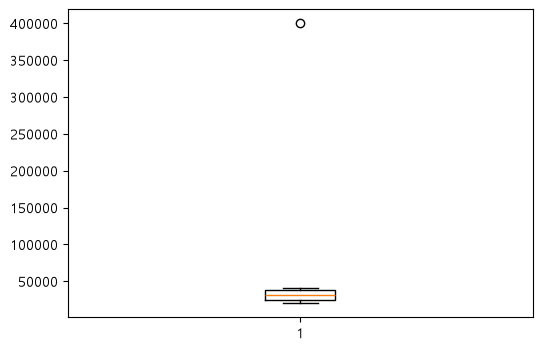

In [66]:
plt.figure(figsize=(6,4))
plt.boxplot(df2["소득"])

plt.show()

# 중간값: .median()

In [69]:
df.fillna(df["소득"].median())

,이름,소득
0,시츄,400000.0
1,하아,32323.0
2,승연,40320.0
3,지성,31161.5
4,혜지,20000.0
5,승기,30000.0
6,우연,23000.0
7,소민,31161.5


## 중복 데이터
- 동일한 데이터가 여러 번 저장된 상태를 의미한다.
- 중복 데이터가 많아지면 통계 결과와 왜곡된 분석 결과 및 신뢰도가 떨어질 수 있습니다.

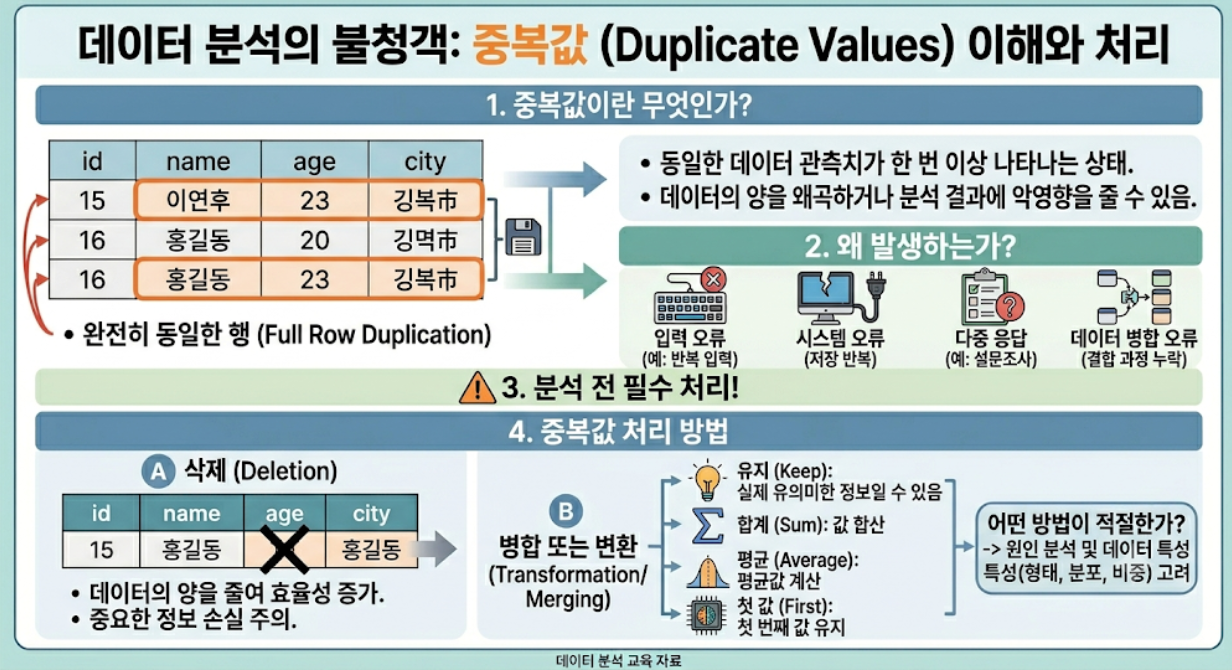

In [70]:
df = pd.DataFrame({
    "이름": ["지호", "승현", "상아", "우영", "우영", "준승", "예나", "수민", "지호", "상아"],
    "취미": ["코딩", "칵테일", "알바", "코딩", "코딩", "코딩", "코딩", "스트레칭", "코딩", "알바"]
})

df

,이름,취미
0,지호,코딩
1,승현,칵테일
2,상아,알바
3,우영,코딩
4,우영,코딩
5,준승,코딩
6,예나,코딩
7,수민,스트레칭
8,지호,코딩
9,상아,알바


In [71]:
df.duplicated()

0    False
1    False
2    False
3    False
4     True
5    False
6    False
7    False
8     True
9     True
dtype: bool

In [72]:
df.duplicated().sum()

np.int64(3)

In [73]:
df2 = df.drop_duplicates()
df2

,이름,취미
0,지호,코딩
1,승현,칵테일
2,상아,알바
3,우영,코딩
5,준승,코딩
6,예나,코딩
7,수민,스트레칭


In [75]:
df = pd.DataFrame({
    "학번": [i+1 for i in range(10)],
    "이름": ["지호", "승현", "상아", "우영", "우영", "준승", "예나", "수민", "지호", "상아"],
    "취미": ["코딩", "칵테일", "알바", "코딩", "코딩", "코딩", "코딩", "스트레칭", "코딩", "알바"]
})

df

,학번,이름,취미
0,1,지호,코딩
1,2,승현,칵테일
2,3,상아,알바
3,4,우영,코딩
4,5,우영,코딩
5,6,준승,코딩
6,7,예나,코딩
7,8,수민,스트레칭
8,9,지호,코딩
9,10,상아,알바


In [77]:
df.duplicated(subset=["이름","취미"])
# 이름과 취미만 동일하면 중복 데이터로 판단.

0    False
1    False
2    False
3    False
4     True
5    False
6    False
7    False
8     True
9     True
dtype: bool

In [78]:
df2 = df.drop_duplicates(subset=["이름","취미"])
df2

,학번,이름,취미
0,1,지호,코딩
1,2,승현,칵테일
2,3,상아,알바
3,4,우영,코딩
5,6,준승,코딩
6,7,예나,코딩
7,8,수민,스트레칭


## 데이터 전처리 연습

In [80]:
import os

base_path = r"C:\kdt_0900_osh\data_analysis\resource\dataset"
file_name = r"preprocessing.csv"

file_path = os.path.join(base_path,file_name)

In [81]:
df1 = pd.read_csv(file_path)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


## 1단계. 컬럼 타입 확인
- 각 컬럼이 수치형(Numeric)인지, 범주형/분류형(Categorical)인지 확인해야한다.
- 그 이유는 대체값(Imputation) 전략이 달라지기 때문이다.

1. 수치형 데이터: 평균값 또는 중앙값 또는 특정 값으로 대체
2. 범주형 데이터: 최빈값, 범주 추가하여 처리

In [82]:
df1.info()
# feature 개수: 6개

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      30 non-null     int64  
 1   name    30 non-null     str    
 2   age     29 non-null     float64
 3   gender  30 non-null     str    
 4   city    29 non-null     str    
 5   salary  29 non-null     float64
dtypes: float64(2), int64(1), str(3)
memory usage: 1.5 KB


In [84]:
# 기술통계량
df1.describe()

,id,age,salary
count,30.000000,29.000000,29.000000
mean,15.500000,62.413793,38237.896552
std,8.803408,180.348575,184974.502563
min,1.000000,-5.000000,2700.000000
25%,8.250000,26.000000,3400.000000
50%,15.500000,29.000000,3700.000000
75%,22.750000,34.000000,4500.000000
max,30.000000,999.000000,999999.000000


## 2단계, 각 컬럼 타입의 계획 수립
- id: int(수치가 아닌 분류)
- name: str(분류)
- age: float -> int(수치)
- gender: str(분류)
- city: str(분류)
- salary: int(수치)

## 3단계. 이상치,결측치, 중복값을 확인

In [89]:
# age, city, salary -> 결측치가 존재
df1.isna().sum()

id        0
name      0
age       1
gender    0
city      1
salary    1
dtype: int64

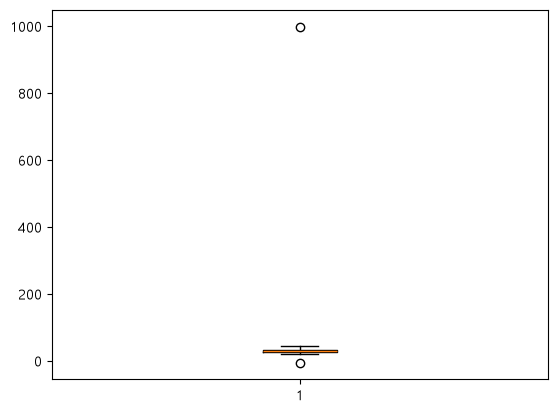

In [91]:
# age -> 이상치 존재
plt.boxplot(df1["age"].dropna())
plt.show()

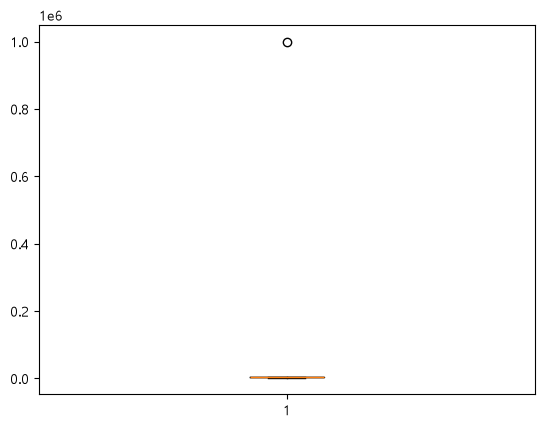

In [93]:
# salary -> 이상치 존재
plt.boxplot(df1["salary"].dropna())
plt.show()

In [95]:
# 1개의 중복 데이터가 존재
df1.duplicated(subset=["name","age","gender","city"]).sum()

np.int64(1)

## 4단계. 결측치 대체

In [104]:
# age, city, salary
# age: 수치형
# -> 평균, 중앙값
# -> 중앙값(median)
age_median = df1["age"].median()
df1["age"] = df1["age"].fillna(age_median)

In [105]:
df1.loc[11]

id            12
name         이다은
age         29.0
gender         여
city          성남
salary    3900.0
Name: 11, dtype: object

In [119]:
# 분류형 데이터
# -> 최빈값(mode), 새로운 컬럼 생성
city_mode = df1["city"].mode()[0]
city_mode

'서울'

In [120]:
df1["city"] = df1["city"].fillna(city_mode)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


In [125]:
# salary 대체값 넣기
# 결측치 존재
df1["salary"].isna()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
Name: salary, dtype: bool

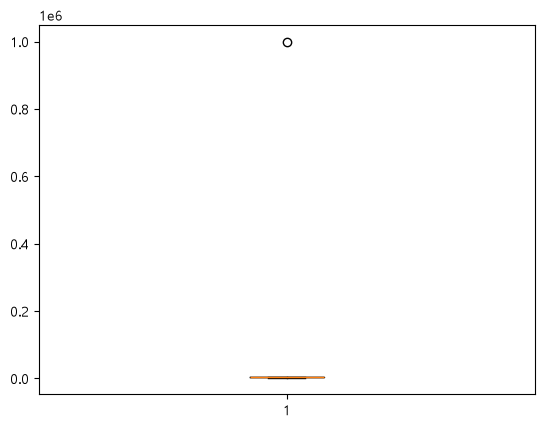

In [129]:
# 수치형 데이터
# -> 평균값, 중앙값
# 이상치 존재 -> 평균 안됨
plt.boxplot(df1["salary"].dropna())
plt.show()

In [134]:
# 중앙값으로 채우기
df1["salary"] = df1["salary"].fillna(df1["salary"].median())
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


## 컬럼의 형변환

In [138]:
df1["age"] = df1["age"].astype(int)
df1["salary"] = df1["salary"].astype(int)

In [139]:
df1

,id,name,age,gender,city,salary
0,1,김철수,28,남,서울,3500
1,2,이영희,31,여,부산,4200
2,3,박민수,25,남,대구,3000
3,4,최지은,29,여,인천,3800
4,5,정수현,34,남,광주,4500
5,6,한유진,27,여,대전,3600
6,7,오세훈,45,남,서울,5500
7,8,강민지,22,여,부산,2800
8,9,윤성호,38,남,울산,4900
9,10,송지수,26,여,서울,3400


## 5단계. 이상치 대체 또는 제거

In [146]:
Q1 = df1["salary"].quantile(0.25)
Q3 = df1["salary"].quantile(0.75)
IQR = Q3 - Q1

print(f"1사분위 값 : {Q1}")
print(f"3사분위 값 : {Q3}")
print(f"IQR : {IQR}")

1사분위 값 : 3425.0
3사분위 값 : 4475.0
IQR : 1050.0


In [149]:
min_outlier = Q1 - (IQR * 1.5)
max_outlier = Q3 + (IQR * 1.5)

print(f"max_outlier : {max_outlier} 초과")
print(f"min_outlier : {min_outlier} 이하")

max_outlier : 6050.0 초과
min_outlier : 1850.0 이하


In [154]:
outlier_mask = (df1["salary"] > max_outlier) | (df1["salary"] < min_outlier)
df1["salary"][outlier_mask]

27    999999
Name: salary, dtype: int64

In [156]:
def remove_outlier(df, col_name):
    df_copy = df.copy()
    
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    mask = ~((df_copy[col_name] > upper) | (df_copy[col_name] < lower))
    return df_copy[mask]

In [167]:
df2 = remove_outlier(df1, "salary")
df3 = remove_outlier(df2, "age")[df3["age"] > 0]

In [168]:
df3

,id,name,age,gender,city,salary
0,1,김철수,28,남,서울,3500
1,2,이영희,31,여,부산,4200
2,3,박민수,25,남,대구,3000
3,4,최지은,29,여,인천,3800
4,5,정수현,34,남,광주,4500
5,6,한유진,27,여,대전,3600
7,8,강민지,22,여,부산,2800
8,9,윤성호,38,남,울산,4900
9,10,송지수,26,여,서울,3400
10,11,김도윤,30,남,수원,4000


In [171]:
df4 = df3.reset_index(drop=True)
df4

,id,name,age,gender,city,salary
0,1,김철수,28,남,서울,3500
1,2,이영희,31,여,부산,4200
2,3,박민수,25,남,대구,3000
3,4,최지은,29,여,인천,3800
4,5,정수현,34,남,광주,4500
5,6,한유진,27,여,대전,3600
6,8,강민지,22,여,부산,2800
7,9,윤성호,38,남,울산,4900
8,10,송지수,26,여,서울,3400
9,11,김도윤,30,남,수원,4000


## 중복값 삭제

In [176]:
# df4.duplicated(subset=["name","age","gender","city"])
df4.drop_duplicates(subset=["name","age","gender","city"]).reset_index(drop=True)

,id,name,age,gender,city,salary
0,1,김철수,28,남,서울,3500
1,2,이영희,31,여,부산,4200
2,3,박민수,25,남,대구,3000
3,4,최지은,29,여,인천,3800
4,5,정수현,34,남,광주,4500
5,6,한유진,27,여,대전,3600
6,8,강민지,22,여,부산,2800
7,9,윤성호,38,남,울산,4900
8,10,송지수,26,여,서울,3400
9,11,김도윤,30,남,수원,4000
